# k-means from scratch

In [1]:
from sklearn import datasets
import numpy as np
from matplotlib import pyplot as plt
from copy import deepcopy

In [2]:
iris = datasets.load_iris()
X = iris.data[:, 2:4]
y = iris.target

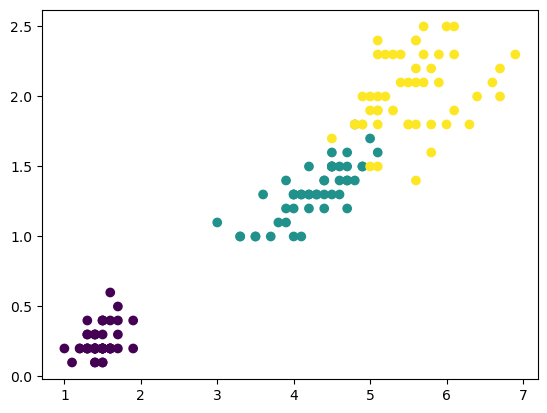

In [3]:
plt.scatter(X[:,0], X[:,1], c=y)
plt.show()

In [4]:
k = 3
random_index = np.random.choice(range(len(X)), k)
centroids = X[random_index]

In [5]:
def visualize_centroids(X, centroids):
    plt.scatter(X[:, 0], X[:, 1])
    plt.scatter(centroids[:, 0], centroids[:, 1], marker='*', s=200, c='#050505')
    plt.show()

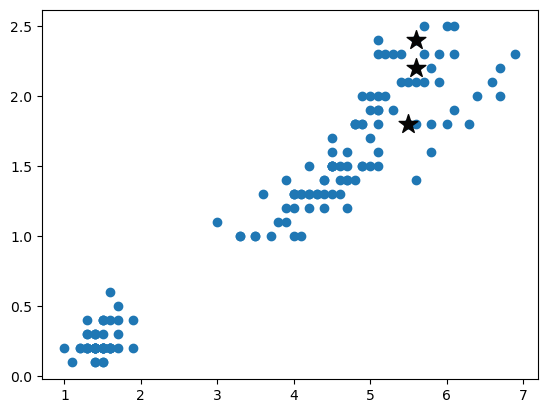

In [6]:
visualize_centroids(X, centroids)

In [7]:
def dist(a, b):
    return np.linalg.norm(a - b, axis=1)

In [8]:
def assign_cluster(x, centroids):
    distances = dist(x, centroids)
    cluster = np.argmin(distances)
    return cluster

In [9]:
def update_centroids(X, centroids, clusters):
    for i in range(k):
        cluster_i = np.where(clusters == i)
        centroids[i] = np.mean(X[cluster_i], axis=0)

In [10]:
clusters = np.zeros(len(X))

tol = 0.0001
max_iter = 100

iter = 0
centroids_diff = 100000

Iteration: 1
Centroids:
 [[3.32258065 0.98145161]
 [5.85714286 2.42857143]
 [5.82631579 2.16842105]]
Centroids move: 2.3517


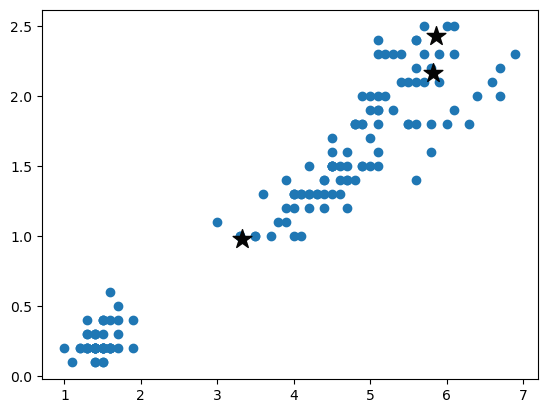

Iteration: 2
Centroids:
 [[2.66263736 0.71318681]
 [5.97       2.38      ]
 [5.34081633 1.86122449]]
Centroids move: 0.9234


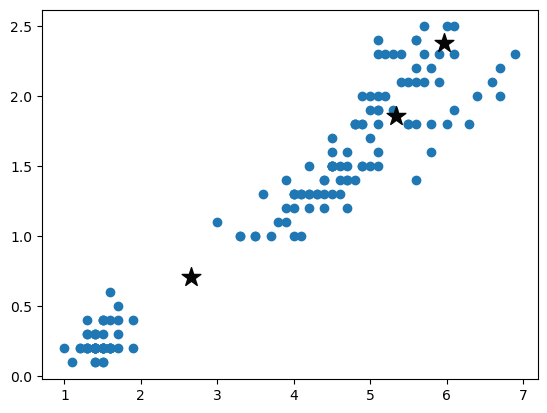

Iteration: 3
Centroids:
 [[1.946875   0.4328125 ]
 [6.07       2.195     ]
 [4.81363636 1.64090909]]
Centroids move: 0.9806


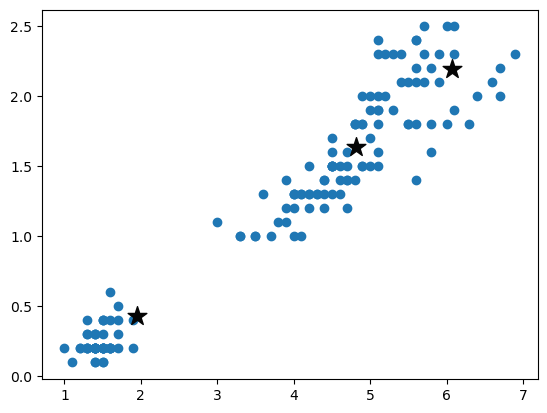

Iteration: 4
Centroids:
 [[1.56037736 0.29056604]
 [5.89333333 2.12      ]
 [4.54029851 1.50597015]]
Centroids move: 0.5471


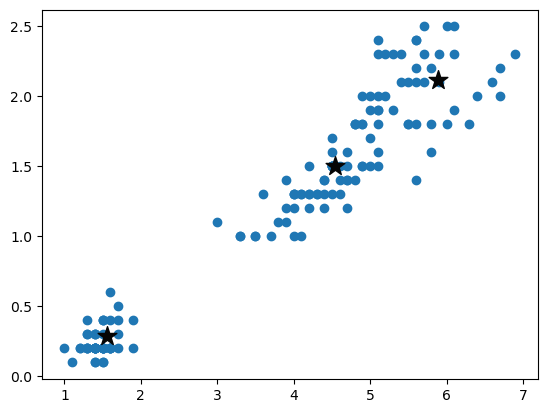

Iteration: 5
Centroids:
 [[1.462      0.246     ]
 [5.78611111 2.10833333]
 [4.4109375  1.4328125 ]]
Centroids move: 0.2130


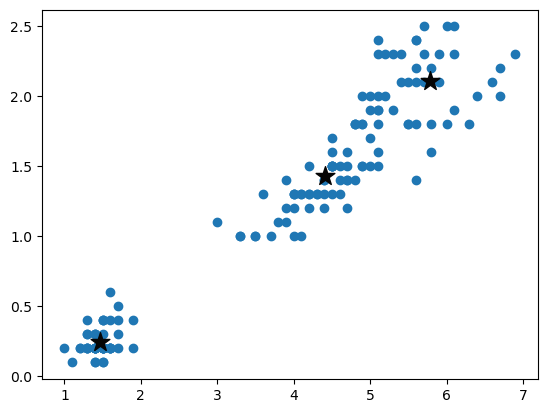

Iteration: 6
Centroids:
 [[1.462      0.246     ]
 [5.7        2.08536585]
 [4.35423729 1.39152542]]
Centroids move: 0.1134


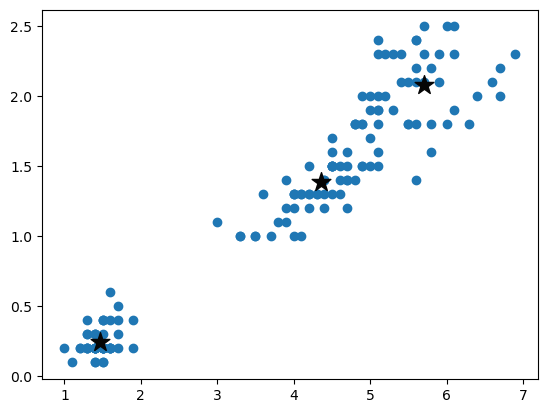

Iteration: 7
Centroids:
 [[1.462      0.246     ]
 [5.65227273 2.06818182]
 [4.31964286 1.36785714]]
Centroids move: 0.0658


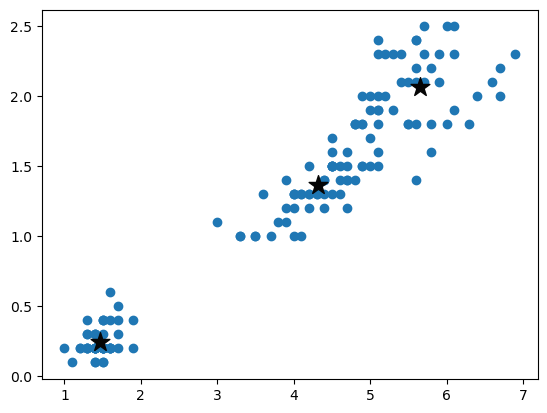

Iteration: 8
Centroids:
 [[1.462      0.246     ]
 [5.63777778 2.06      ]
 [4.30727273 1.36181818]]
Centroids move: 0.0216


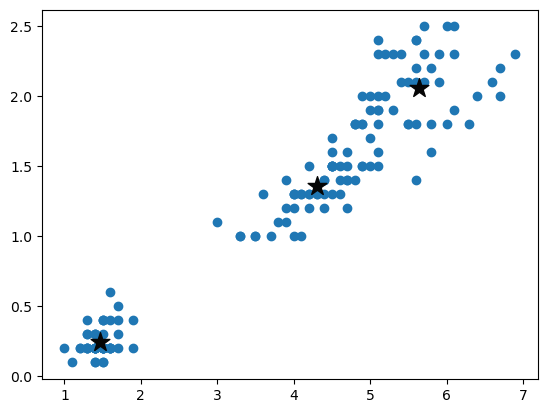

Iteration: 9
Centroids:
 [[1.462      0.246     ]
 [5.62608696 2.04782609]
 [4.29259259 1.35925926]]
Centroids move: 0.0225


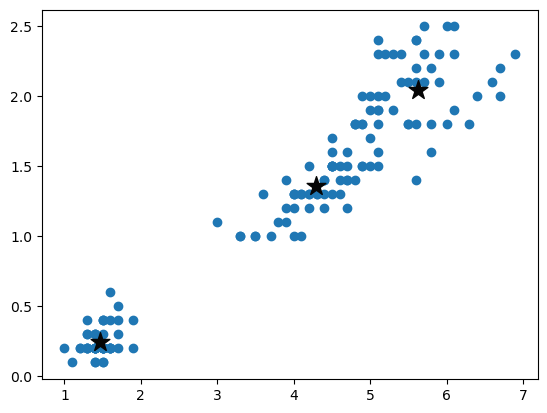

Iteration: 10
Centroids:
 [[1.462      0.246     ]
 [5.62608696 2.04782609]
 [4.29259259 1.35925926]]
Centroids move: 0.0000


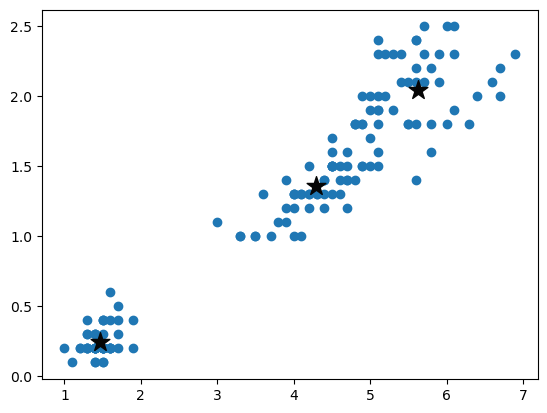

In [11]:
while iter < max_iter and centroids_diff > tol:
    for i in range(len(X)):
        clusters[i] = assign_cluster(X[i], centroids)
    centroids_prev = deepcopy(centroids)
    update_centroids(X, centroids, clusters)
    iter += 1
    centroids_diff = np.linalg.norm(centroids - centroids_prev)
    print('Iteration:', str(iter))
    print('Centroids:\n', centroids)
    print('Centroids move: {:5.4f}'.format(centroids_diff))
    visualize_centroids(X, centroids)

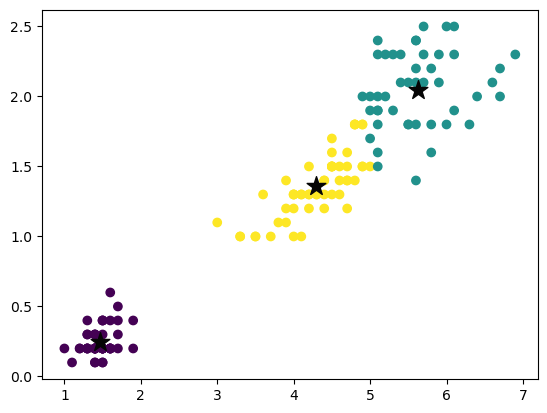

In [12]:
plt.scatter(X[:, 0], X[:, 1], c=clusters)
plt.scatter(centroids[:, 0], centroids[:, 1], marker='*', s=200, c='#050505')
plt.show()

## sklearn

In [13]:
from sklearn.cluster import KMeans

In [14]:
kmeans_sk = KMeans(n_clusters=3, random_state=42)
kmeans_sk.fit(X)
clusters_sk = kmeans_sk.labels_
centroids_sk = kmeans_sk.cluster_centers_

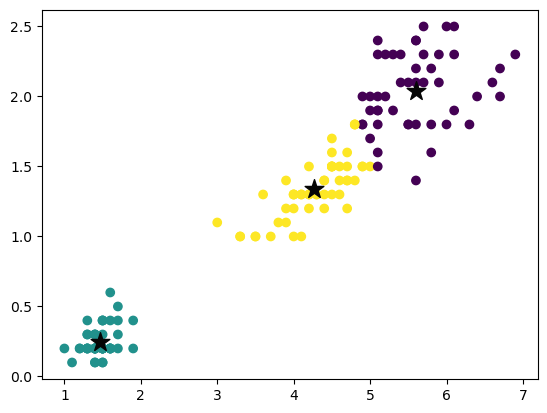

In [15]:
plt.scatter(X[:, 0], X[:, 1], c=clusters_sk)
plt.scatter(centroids_sk[:, 0], centroids_sk[:, 1], marker='*', s=200, c='#050505')
plt.show()

## Elbow method

In [16]:
k_list = list(range(1, 7))
sse_list = [0] * len(k_list)

In [17]:
for k_ind, k in enumerate(k_list):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X)
    clusters = kmeans.labels_
    centroids = kmeans.cluster_centers_

    sse = 0
    for i in range(k):
        cluster_i = np.where(clusters == i)

        sse += np.linalg.norm(X[cluster_i] - centroids[i])

    print('k={}, SSE={}'.format(k, sse))
    sse_list[k_ind] = sse

k=1, SSE=23.47115960776828
k=2, SSE=11.267116838758653
k=3, SSE=9.071807045694348
k=4, SSE=8.447701634097278
k=5, SSE=8.263529314616575
k=6, SSE=7.988339531914781


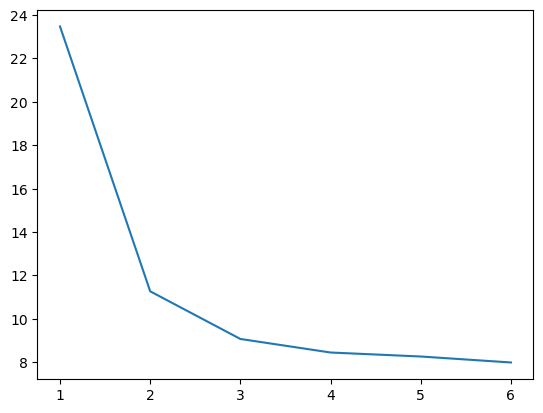

In [18]:
plt.plot(k_list, sse_list)
plt.show()